# E-commerce Growth Analysis

## Goal
Identify key drivers of revenue growth and constraints (retention, AOV, regional dependency)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

## Data overview

In [2]:
df_orders = pd.read_csv('../data/raw/olist_orders_dataset.csv')
df_order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
df_products = pd.read_csv('../data/raw/olist_products_dataset.csv')
df_customers = pd.read_csv('../data/raw/olist_customers_dataset.csv')
df_sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')

In [3]:
df_orders.shape

(99441, 8)

In [4]:
df_order_items.shape

(112650, 7)

In [5]:
df_products.shape

(32951, 9)

In [6]:
df_customers.shape

(99441, 5)

In [7]:
df_sellers.shape

(3095, 4)

## Data preparation

In [8]:
conn = sqlite3.connect('../data/database/data_mart.db') 

In [9]:
query = """
SELECT 
    order_items.order_id,
    order_items.order_item_id,
    order_items.product_id,

    orders.customer_id,
    customers.customer_unique_id,

    orders.order_purchase_timestamp,
    orders.order_delivered_customer_date,

    order_items.price,
    order_items.freight_value,
    (order_items.price + order_items.freight_value) AS revenue,

    products.product_category_name,

    customers.customer_city,
    customers.customer_state

FROM order_items 

LEFT JOIN orders  
    ON order_items.order_id = orders.order_id
    AND orders.order_purchase_timestamp >= '2017-01-01'
    AND orders.order_purchase_timestamp <= '2018-09-01'

LEFT JOIN products  
    ON order_items.product_id = products.product_id

LEFT JOIN customers 
    ON orders.customer_id = customers.customer_id
"""

data_mart = pd.read_sql(query, conn)

In [10]:
pd.read_sql("SELECT * FROM data_mart LIMIT 5",conn)

,order_id,order_item_id,product_id,customer_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,price,freight_value,revenue,product_category_name,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,2017-09-13 08:59:02,2017-09-20 23:43:48,58.90,13.29,72.19,cool_stuff,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,2017-04-26 10:53:06,2017-05-12 16:04:24,239.90,19.93,259.83,pet_shop,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,2018-01-14 14:33:31,2018-01-22 13:19:16,199.00,17.87,216.87,moveis_decoracao,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,2018-08-08 10:00:35,2018-08-14 13:32:39,12.99,12.79,25.78,perfumaria,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,2017-02-04 13:57:51,2017-03-01 16:42:31,199.90,18.14,218.04,ferramentas_jardim,varzea paulista,SP


## EDA

## Analysis of the number and revenue of orders by month

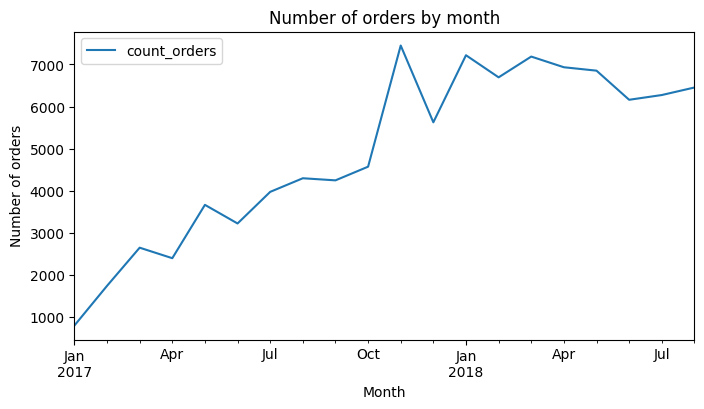

In [11]:
orders_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(*) AS count_orders
    FROM orders_agg
    GROUP BY month
    """, conn)
orders_per_months['month'] = pd.to_datetime(orders_per_months['month'])
orders_per_months.set_index('month', inplace=True)
orders_per_months.plot(figsize=(8,4))
plt.title('Number of orders by month')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.show()

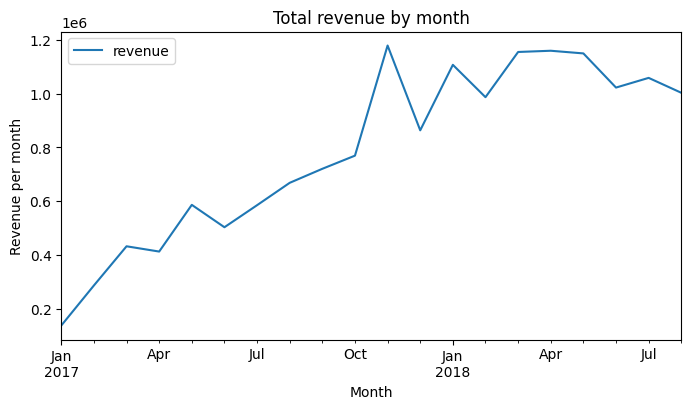

In [12]:
revenue_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(revenue) AS revenue
    FROM orders_agg
    GROUP BY month
    """, conn)
revenue_per_months['month'] = pd.to_datetime(revenue_per_months['month'])
revenue_per_months.set_index('month', inplace=True)
revenue_per_months.plot(figsize=(8,4))
plt.title('Total revenue by month')
plt.xlabel('Month')
plt.ylabel('Revenue per month')
plt.show()

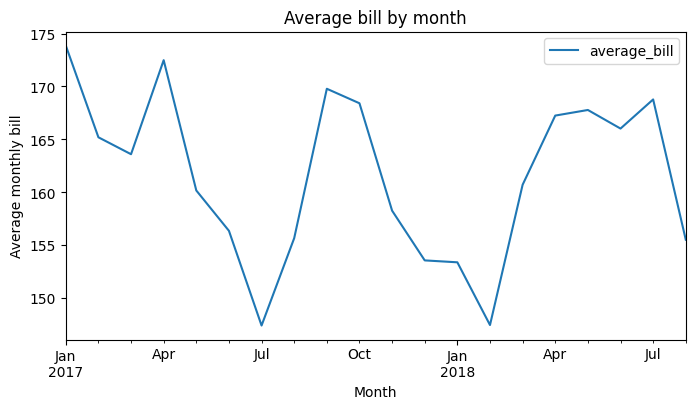

In [13]:
averagebill_per_months = pd.read_sql(
    """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        SUM(revenue)/COUNT(*) AS average_bill
    FROM orders_agg
    GROUP BY month
    """, conn)
averagebill_per_months['month'] = pd.to_datetime(averagebill_per_months['month'])
averagebill_per_months.set_index('month', inplace=True)
averagebill_per_months.plot(figsize=(8,4))
plt.title('Average bill by month')
plt.xlabel('Month')
plt.ylabel('Average monthly bill')
plt.show()

#### Insights:
- Revenue growth is driven by increasing order volume (7000 peak in Nov 2017)
- AOV remains stable (150 – 175), indicating no efficiency improvement

## Analysis by region

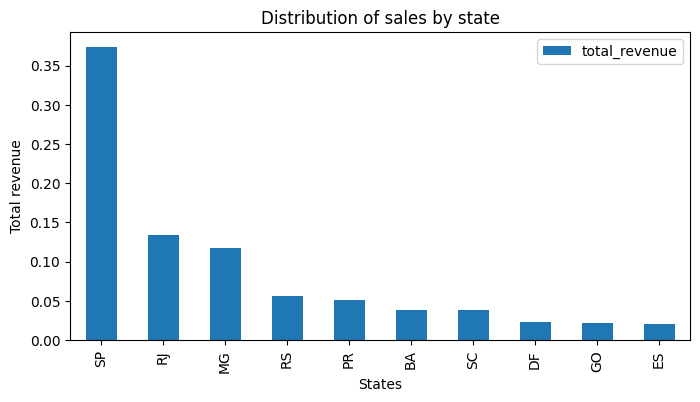

In [14]:
revenue_by_states = pd.read_sql(
    """
    SELECT
        SUM(revenue) / (SELECT SUM(revenue) from data_mart) AS total_revenue,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY total_revenue DESC
    LIMIT 10
    """, conn)
revenue_by_states.set_index('customer_state', inplace=True)
revenue_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of sales by state')
plt.xlabel('States')
plt.ylabel('Total revenue')
plt.show()

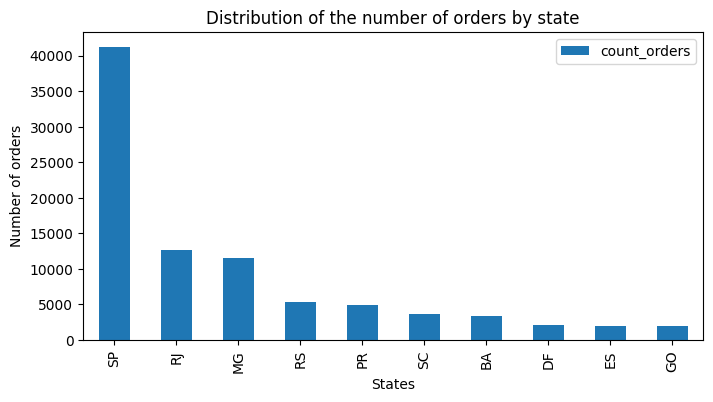

In [15]:
count_orders_by_states = pd.read_sql(
    """
    SELECT
        COUNT(order_id) AS count_orders,
        customer_state
    FROM orders_agg
    GROUP BY customer_state
    ORDER BY count_orders DESC
    LIMIT 10
    """, conn)
count_orders_by_states.set_index('customer_state', inplace=True)
count_orders_by_states.plot(kind='bar', figsize=(8,4))
plt.title('Distribution of the number of orders by state')
plt.xlabel('States')
plt.ylabel('Number of orders')
plt.show()

#### Insights:
- Sales are highly concentrated in SP (40% of revenue and orders), driven by volume rather than higher AOV
- High-AOV states (PB, AC, AP, AL, RO) have low sales volume, while high-volume states (SP, RJ, MG, RS, PR) show lower AOV

## Customer behavior analysis

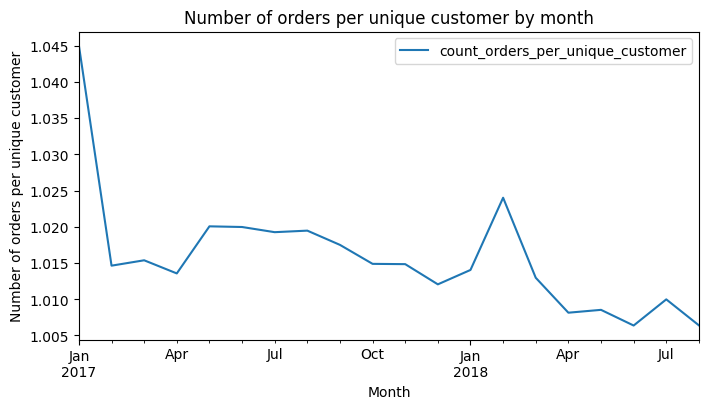

In [16]:
count_orders_per_unique_customer = pd.read_sql(
    """
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(DISTINCT order_id) / CAST(COUNT(DISTINCT customer_unique_id) AS float) AS count_orders_per_unique_customer
    FROM data_mart
    GROUP BY month
    """,conn)
count_orders_per_unique_customer['month'] = pd.to_datetime(count_orders_per_unique_customer['month'])
count_orders_per_unique_customer.set_index('month', inplace=True)
count_orders_per_unique_customer.plot(figsize=(8,4))
plt.title('Number of orders per unique customer by month')
plt.xlabel('Month')
plt.ylabel('Number of orders per unique customer')
plt.show()

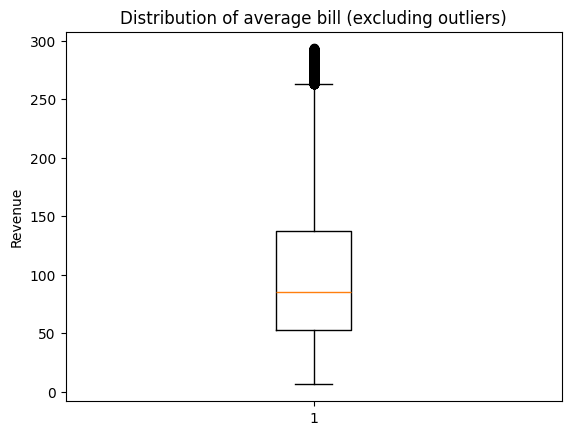

In [17]:
df_data_mart_limited = pd.read_sql(
    """
    SELECT 
        revenue
    FROM data_mart
    WHERE revenue < 500
    """,conn)

q95 = df_data_mart_limited['revenue'].quantile(0.95)
plt.boxplot(df_data_mart_limited[df_data_mart_limited['revenue'] < q95]['revenue'])
plt.title('Distribution of average bill (excluding outliers)')
plt.ylabel('Revenue')
plt.show()

#### Insights:
- Average orders per customer = 1,03, extremely low repeat purchase rate  
- Customer base is dominated by one-time buyers  
- Slight downward trend driven by influx of new single-purchase customers

## Business problems:
1. Low customer retention

In [18]:
count_orders_per_unique_customer = pd.read_sql(
    """
    SELECT 
        COUNT(DISTINCT order_id) / CAST(COUNT(DISTINCT customer_unique_id) AS float) AS count_orders_per_unique_customer 
    FROM data_mart
    """, conn)
count_orders_per_unique_customer.set_index('count_orders_per_unique_customer', inplace=True)
count_orders_per_unique_customer

""
count_orders_per_unique_customer
1.033978


## Hypothesis 1: Categories impact retention

**Conclusion:** Not confirmed

## Hypothesis 2: Delivery time impacts retention

**Result:**
- Median delivery time = 10 days  
- Regions with faster delivery - higher activity  
- Regions with 15+ days - lower activity  

**Conclusion:** Partially confirmed

## Hypothesis 3 – 4: сustomer experience and marketing impact retention

**Result:**
- No data on customer experience or marketing  

**Conclusion:** Not testable

---

2. High dependence on SP state

## Hypothesis 1: Seller concentration in SP drives regional imbalance

**Result:**
- about 60% of sellers are located in SP  
- about 40% of orders and revenue come from SP  
- Revenue per seller in SP is among the lowest (117)  
- Orders per seller are highest (37), while AOV is lowest (190)

- Other regions (RS, RJ, SC, PR):
  - Lower orders per seller  
  - Higher AOV (240 – 280)  
  - Higher revenue per seller  

**Conclusion:** Confirmed

## Hypothesis 2: Traffic / demand imbalance (not testable)

**Note:**
- No data on marketing channels or ad spend  

**Conclusion:** Not testable

---

3. Revenue concentration in high-value orders

## Hypothesis 1: Revenue is driven by high-value customers

**Result:**
- Top 5% of orders generate about 34% of revenue  
- Majority of customers are one-time buyers  
- No significant loyal/VIP segment (RFM)  

**Conclusion:** Not confirmed  
Revenue is not driven by a stable high-value customer base

## Hypothesis 2: High-value orders are driven by product factors

**Result:**

High-value orders are disproportionately concentrated in specific product categories.

Top categories such as:
- relogios_presentes (2,6x)
- consoles_games (2,3x)
- beleza_saude (1,8x)

are significantly overrepresented in the top 5% of orders compared to their baseline share.

This indicates that certain categories have a much higher likelihood of generating high-value transactions.

**Conclusion:** Confirmed. Product category is a key driver of high-value orders. A small group of categories contributes disproportionately to high-revenue transactions.

## Recommendations
- Fix customer retention (focus on one-time customers, using reactivation campaigns, prioritize high-value one-time customers for retention efforts)
- Logistics optimization (prioritize logistics improvements in regions with delivery times >15 days)
- Scale high-value categories (promote high-value products through homepage placement and recommendation blocks, use upsell and recommendation systems)
- Reduce dependency on SP (expand seller base in high AOV regions)
- Increase AOV in SP (promote premium alternatives, use recommendation blocks)